# I. initialize data

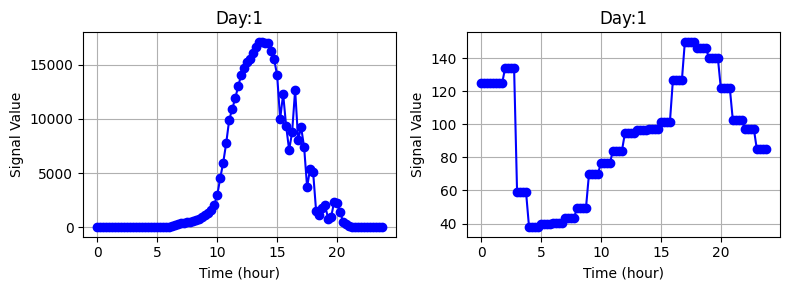

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from modules.solar import PVdata
from modules.economy import ElecPrice

pv_data_path = './data/timeseries-slimpark-2022.csv'
price_data_path='./data/day_ahead_prices_2022.csv'
PV_panel = PVdata(pv_data_path)
elec_price = ElecPrice(price_data_path)

expanded_pv = np.hstack([np.zeros(1,), PV_panel.day_data])
expanded_price = np.hstack([np.zeros(1,), elec_price.day_price_data])

# Create time axis for original and expanded data
time_axis_original = np.arange(0, 24, 1)
time_axis_expanded = np.arange(0, 24, 0.25)

# Plot the original and expanded data in subplots
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1)
plt.plot(time_axis_expanded, expanded_pv[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)

plt.subplot(1,2,2)
# plt.plot(time_axis_original.astype(str), price_day[1:], marker='o', linestyle='-', color='g', label='Original Data (1 hour)')
plt.plot(time_axis_expanded, expanded_price[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)
plt.tight_layout()
plt.show()


Total number of profiles: 2920


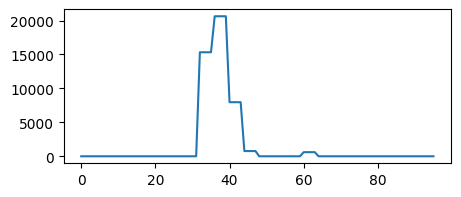

In [2]:
import pandas as pd
import numpy as np

# Load and preprocess data
df = pd.read_csv('data/power_and_active_sessions_cp_UT.csv')
df['date'] = pd.to_datetime(df['times']).dt.date

# Group by date
grouped = df.groupby('date')

# Initialize storage dictionaries
evse_cols = ['evse_1_wh', 'evse_2_wh', 'evse_3_wh', 'evse_4_wh']
evse_data = {col: [] for col in evse_cols}
power_profiles = []

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in evse_cols:
            evse_data[col].append(group[col].to_numpy())
        power_profiles.append(group['power'].to_numpy())

# Convert lists to numpy arrays
for col in evse_cols:
    evse_data[col] = np.array(evse_data[col])
    evse_data[col] = np.where(evse_data[col] < 10, 0, evse_data[col])

power_profiles = np.array(power_profiles)
power_profiles = np.where(power_profiles < 10, 0, power_profiles)

# Optional: unpack if you want the original variable names
evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh = (evse_data[col] for col in evse_cols)

all_profiles = np.concatenate((evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh), axis=0)
print(f"Total number of profiles: {len(all_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_profiles[12])

Total number of profiles: 730


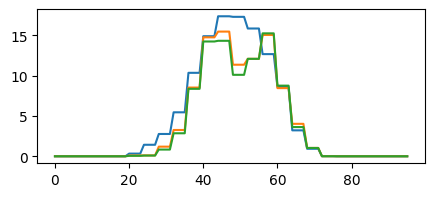

In [3]:
# Initialize storage dictionaries
pv_cols = ['pv_wh', 'pv_forecast_day_ahead_wh', 'pv_forecast_intraday_wh']
pv_data = {col: [] for col in pv_cols}

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in pv_cols:
            pv_data[col].append(group[col].to_numpy())

# Convert lists to numpy arrays
for col in pv_data:
    pv_data[col] = np.array(pv_data[col])
    pv_data[col] = np.where(pv_data[col] < 0, pv_data[col], 0)

# Optional: unpack if you want the original variable names
pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh = (pv_data[col] for col in pv_cols)

all_pv_profiles = -np.stack((pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh), axis=-1)
print(f"Total number of profiles: {len(all_pv_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_pv_profiles[100]/1000)

In [4]:
co2_df = pd.read_csv('data/CO2_2022.csv')
co2_df['validfrom (UTC)'] = pd.to_datetime(co2_df['validfrom (UTC)'])

# Extract year, month, day, and hour from the datetime
co2_df['Year'] =  co2_df['validfrom (UTC)'].dt.year
co2_df['Month'] = co2_df['validfrom (UTC)'].dt.month
co2_df['Day'] =   co2_df['validfrom (UTC)'].dt.day
co2_df['Hour'] =  co2_df['validfrom (UTC)'].dt.hour

# Select a specific day (e.g., January 1, 2022)
specific_day = co2_df[(co2_df['Year'] == 2022) & (co2_df['Month'] == 1) & (co2_df['Day'] == 1)]
co2_repeated = np.repeat(specific_day['emissionfactor (kg CO2/kWh)'], 4)

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assume all_profiles is defined
start_times, durations, energy_consumptions = [], [], []

# Extract features from all_profiles
for prof_id in np.unique(np.where(all_profiles > 10)[0]):
    profile = all_profiles[prof_id]
    active_indices = np.where(profile > 0)[0]
    if len(active_indices) == 0:
        continue
    start = active_indices[0] / 4
    duration = len(active_indices) / 4
    energy = profile[active_indices].sum()/1000
    start_times.append(start)
    durations.append(duration)
    energy_consumptions.append(energy)
    
ev_data = torch.tensor(np.stack([start_times, durations, energy_consumptions], axis=1))

In [6]:
expanded_pv = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 0]])
expanded_pv_forecast = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 1]])
expanded_emmision = np.hstack([np.zeros(1,), co2_repeated.to_numpy()])

# II. MDN

In [73]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

class MDN(nn.Module):
    def __init__(self, input_dim, output_dim, n_components=3, hidden_dim=64):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)                                     # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)           # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        target = target.unsqueeze(1)                                           # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * np.pi)**0.5)
        prob = prob.prod(dim=-1)                                               # (B, K)
        weighted = pi * prob
        return torch.log(weighted.sum(dim=-1) + 1e-8)                           # (B,)

    def sample(self, pi, mu, sigma):
        batch_size = pi.size(0)
        cat = torch.distributions.Categorical(pi)
        indices = cat.sample()                                                 # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        sigma_selected = sigma[torch.arange(batch_size), indices]
        eps = torch.randn_like(mu_selected)
        return mu_selected + sigma_selected * eps                              # (B, D)

mdn1 = MDN(input_dim=1, output_dim=1)       # p(arrival)
mdn2 = MDN(input_dim=1, output_dim=1)       # p(duration | arrival)
mdn3 = MDN(input_dim=2, output_dim=1)       # p(energy | arrival, duration)

optim = torch.optim.Adam(
    list(mdn1.parameters()) +
    list(mdn2.parameters()) +
    list(mdn3.parameters()), lr=1e-2
)

for epoch in range(8001):
    batch = ev_data  # shape: (B, 3)
    arrival = batch[:, 0:1].float()+2
    duration = batch[:, 1:2].float()
    energy = batch[:, 2:3].float()

    # MDN1: p(arrival)
    pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
    logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

    # MDN2: p(duration | arrival)
    pi2, mu2, sigma2 = mdn2(arrival)
    logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

    # MDN3: p(energy | arrival, duration)
    x3 = torch.cat([arrival, duration], dim=1)
    pi3, mu3, sigma3 = mdn3(x3)
    logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

    # Total negative log-likelihood loss
    loss = -(logp1 + logp2 + logp3).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

Epoch 0, Loss = 38.9481
Epoch 1000, Loss = 9.1555
Epoch 2000, Loss = 9.1461
Epoch 3000, Loss = 9.1400
Epoch 4000, Loss = 9.0874
Epoch 5000, Loss = 9.0976
Epoch 6000, Loss = 9.1166
Epoch 7000, Loss = 9.1117
Epoch 8000, Loss = 9.1306


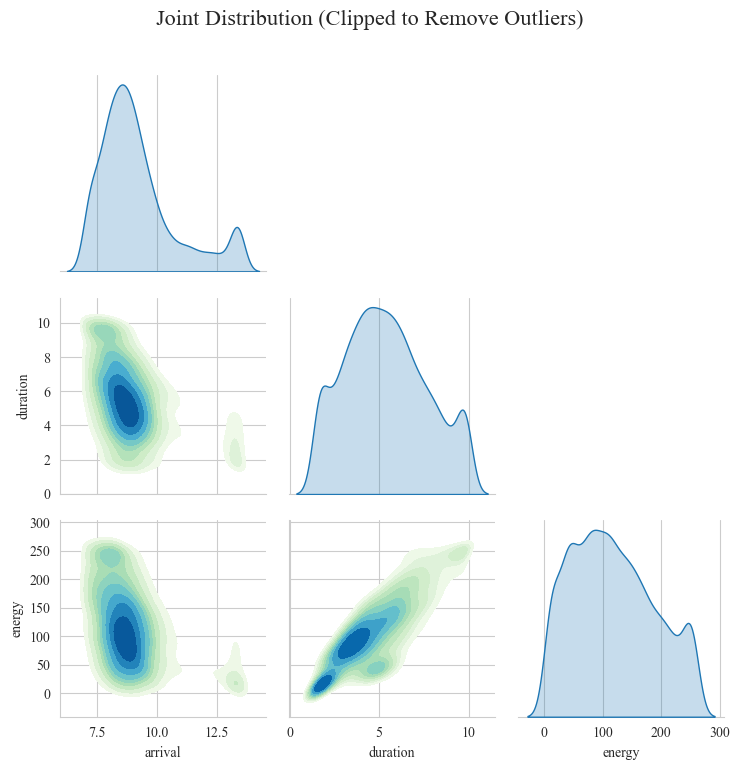

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000):
    device = next(mdn1.parameters()).device

    # Step 1: sample x1 ~ p(x1)
    dummy_input = torch.rand(n_samples, 1).to(device)
    pi1, mu1, sigma1 = mdn1(dummy_input)
    x1 = mdn1.sample(pi1, mu1, sigma1)  # shape: (N, 1)

    # Step 2: sample x2 ~ p(x2 | x1)
    pi2, mu2, sigma2 = mdn2(x1)
    x2 = mdn2.sample(pi2, mu2, sigma2)  # shape: (N, 1)

    # Step 3: sample x3 ~ p(x3 | x1, x2)
    x12 = torch.cat([x1, x2], dim=1)
    pi3, mu3, sigma3 = mdn3(x12)
    x3 = mdn3.sample(pi3, mu3, sigma3)  # shape: (N, 1)

    # Final samples (N, 3)
    samples = torch.cat([x1, x2, x3], dim=1).detach().cpu().numpy()
    return samples


# Generate samples
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)

# Convert to DataFrame for seaborn
df_samples = pd.DataFrame(samples, columns=["arrival", "duration", "energy"])

def clip_outliers(df, lower=0.01, upper=0.99):
    return df.apply(lambda x: x.clip(lower=x.quantile(lower), upper=x.quantile(upper)))

df_clipped = clip_outliers(df_samples, lower=0.05, upper=0.95)

# Pairplot (joint distribution visualization)
# sns.pairplot(df_clipped, kind="kde", corner=True, plot_kws={"fill": True, "thresh": 0.05}
             
# sns.set(style="whitegrid")

g = sns.pairplot(
    df_clipped,
    kind="kde",  # use KDE for joint distributions
    diag_kind="kde",  # KDE for the diagonal too
    plot_kws={'cmap': 'GnBu', 'fill': True, 'thresh': 0.2},
    corner=True  # optional: only show lower triangle
)

plt.suptitle("Joint Distribution (Clipped to Remove Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_2800\1611227703.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


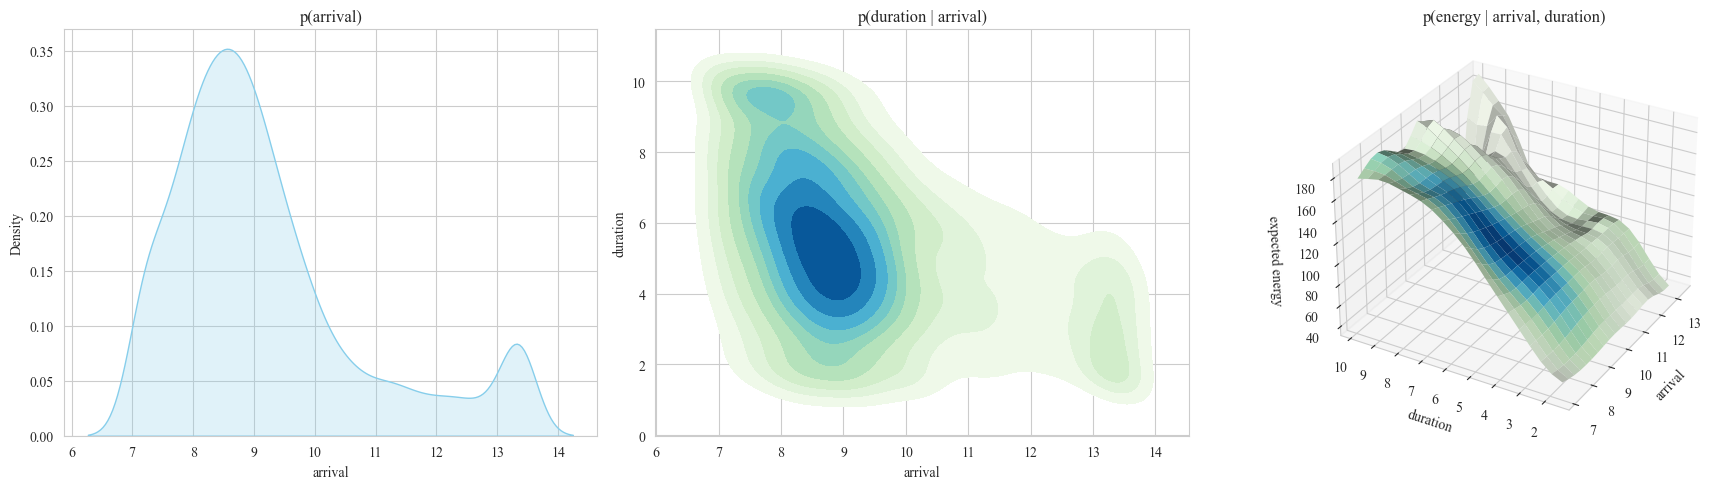

In [ ]:
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def truncate_colormap(cmap_name, minval=0.3, maxval=1.0, n=100):
    cmap = cm.get_cmap(cmap_name)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap_name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

dark_gnbu = truncate_colormap('GnBu', 0.0, 1.0)


fig = plt.figure(figsize=(18, 5))

# 1D: p(arrival)
ax1 = fig.add_subplot(1, 3, 1)
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', ax=ax1)
ax1.set_title('p(arrival)')


# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05,
    ax=ax2
)
ax2.set_title('p(duration | arrival)')

'''
# 3D: p(energy | arrival, duration)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(df_clipped['arrival'], df_clipped['duration'], df_clipped['energy'], c=df_clipped['energy'], cmap=dark_gnbu, s=5)
ax3.set_xlabel('arrival')
ax3.set_ylabel('duration')
ax3.set_zlabel('energy')
ax3.set_title('p(energy | arrival, duration)')
'''

# 3D: p(energy | arrival, duration) with density color
ax4 = fig.add_subplot(1, 3, 3, projection='3d')
# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Compute expected energy and density
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Evaluate KDE density over energy range
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        # Compute marginal density p(arrival, duration) by integrating over energy
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        # Compute expected energy: sum(density * energy) / sum(density)
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])  # Fallback to mean energy

# Normalize density_values for colormap (0 to 1)
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Plot the surface with density color using custom colormap
surf = ax4.plot_surface(X, Y, Z, facecolors=dark_gnbu(density_norm), edgecolor='none', alpha=1)

ax4.set_xlabel('arrival')
ax4.set_ylabel('duration')
ax4.set_zlabel('expected energy')
ax4.set_title('p(energy | arrival, duration)')
# fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

# Set rotation: elevation (30 degrees) and azimuth (-150 degrees)
ax4.view_init(elev=30, azim=-150)

plt.tight_layout()
plt.show()

### Plot distributions seperately

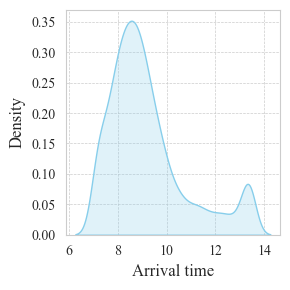

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(3, 3))
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', linewidth=1)
# plt.title('p(arrival)')

plt.xlabel('Arrival time', fontsize=12)
plt.ylabel('Density', fontsize=12)
# plt.title('Battery Energy Storage')
# plt.legend(loc='lower right', fontsize=9)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('p1.png', dpi=300, bbox_inches='tight', pad_inches=0)  # Save with 300 DPI


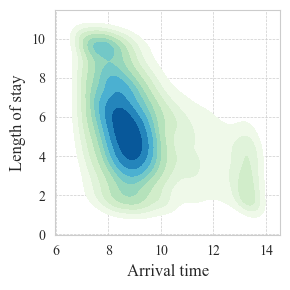

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(3, 3))

# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05
)
# plt.title('${p(l \mid a)}$')

plt.xlabel('Arrival time', fontsize=12)
plt.ylabel('Length of stay', fontsize=12)
# plt.title('Battery Energy Storage')
# plt.legend(loc='lower right', fontsize=9)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('p2.png', dpi=300, bbox_inches='tight', pad_inches=0)  # Save with 300 DPI


C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_2800\115203872.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('GnBu')


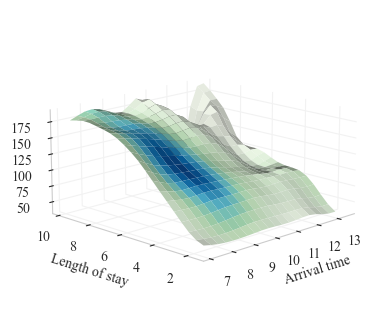

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib import cm

# Set seaborn and matplotlib styles
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Dummy data (replace with your own df_clipped)
# Example:
# df_clipped = pd.read_csv("your_data.csv")
# Ensure df_clipped has columns: 'arrival', 'duration', 'energy'

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 3, 3, projection='3d')

# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Energy range for integration
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)

# Compute KDE-based expected energy and marginal density
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])

# Normalize density for color mapping
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Use a colormap (replace with your own if needed)
colormap = cm.get_cmap('GnBu')
colors = colormap(density_norm)

# Plot the surface
surf = ax.plot_surface(X, Y, Z, facecolors=colors, edgecolor='none', alpha=1)

# Label axes and title
ax.set_xlabel('Arrival time', fontsize=10)
ax.set_ylabel('Length of stay', fontsize=10)
ax.set_zlabel('Energy demand', fontsize=10)
# ax.set_title('p(energy | arrival, duration)', fontsize=10)

# Adjust 3D view
ax.view_init(elev=15, azim=-135)
ax.set_box_aspect([1, 1, 0.5])  # squash height
# Set background of the panes (walls) to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # White
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Make gridlines very light gray (almost white)
light_gray = (0.95, 0.95, 0.95, 1.0)
ax.xaxis._axinfo["grid"]['color'] = light_gray
ax.yaxis._axinfo["grid"]['color'] = light_gray
ax.zaxis._axinfo["grid"]['color'] = light_gray


# Grid, layout, and save
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('p3.png', dpi=300, bbox_inches='tight', pad_inches=0.4)
plt.show()

# III. Dist-Aware MPC

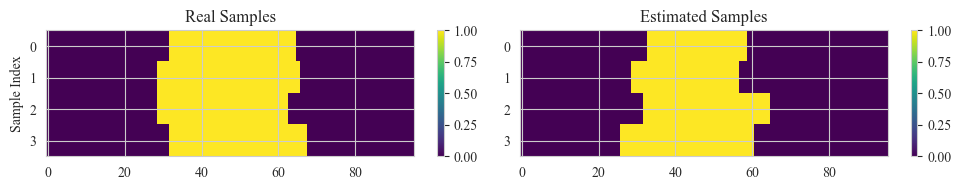

In [79]:
import numpy as np
import matplotlib.pyplot as plt

def get_filtered_samples(mdn1, mdn2, mdn3, n_samples=5000, n_return=4):
    samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=n_samples)
    arrival_samples = samples[:, 0]
    duration_samples = samples[:, 1]
    energy_samples = samples[:, 2]

    # Filter the samples
    mask = (arrival_samples >= 0) & (duration_samples >= 6) & (energy_samples >= 0)
    filtered_arrivals = arrival_samples[mask][:n_return]
    filtered_durations = duration_samples[mask][:n_return]
    filtered_energies = energy_samples[mask][:n_return]

    return filtered_arrivals, filtered_durations, filtered_energies/4

def compute_availability(arrival_times, durations, n_slots=96):
    n_samples = len(arrival_times)
    # Convert hours to 15-minute slots (vectorized)
    arrival_slots = np.clip((arrival_times * 4).astype(int), 0, n_slots - 1)
    duration_slots = (durations * 4).astype(int)
    departure_slots = arrival_slots + duration_slots
    # Create time slot indices for broadcasting
    slot_indices = np.arange(n_slots)  # Shape: (n_slots,)
    start_mask = slot_indices >= arrival_slots[:, None]  # (n_samples, n_slots)
    # Handle normal case (departure within day) and wrap-around case
    normal_case = departure_slots <= n_slots
    end_mask_normal = slot_indices < departure_slots[:, None]  # (n_samples, n_slots)
    end_mask_wraparound = slot_indices < (departure_slots % n_slots)[:, None]  # (n_samples, n_slots)
    # Create availability matrix
    availability_matrix = np.zeros((n_samples, n_slots), dtype=int)
    # Normal case: within same day
    normal_mask = normal_case[:, None]  # (n_samples, 1)
    availability_matrix = np.where(
        normal_mask,
        start_mask & end_mask_normal,
        start_mask | end_mask_wraparound  # Wrap-around case
    )
    return availability_matrix.astype(int)

# Sample once for real
real_arrivals, real_durations, real_energies = get_filtered_samples(mdn1, mdn2, mdn3)

# Sample once for estimate
est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)

real_availability_matrix = compute_availability(real_arrivals, real_durations)
est_availability_matrix = compute_availability(est_arrivals, est_durations)

# Plotting with imshow
fig, axs = plt.subplots(1, 2, figsize=(10, 2))

im0 = axs[0].imshow(real_availability_matrix, aspect='auto', cmap='viridis')
axs[0].set_title("Real Samples")
axs[0].set_yticks(range(4))
axs[0].set_ylabel("Sample Index")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(est_availability_matrix, aspect='auto', cmap='viridis')
axs[1].set_title("Estimated Samples")
axs[1].set_yticks(range(4))
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()


In [80]:
def sample_duration_given_arrival(mdn2, arrival):
    """Sample duration given a specific arrival time."""
    # sample x2 ~ p(x2 | x1)
    arrival_tensor = torch.tensor(arrival).reshape(-1,1).float()  # shape: (1, 1)
    pi2, mu2, sigma2 = mdn2(arrival_tensor)
    duration_sample = mdn2.sample(pi2, mu2, sigma2)  # shape: (1, 1)
    return duration_sample.detach().numpy().flatten()

sample_duration_given_arrival(mdn2, [9])

array([6.526126], dtype=float32)

In [81]:
# Sample once for estimate
est_arrivals_temp, est_durations_temp, est_energies_temp = est_arrivals.copy(), est_durations.copy(), est_energies.copy()
est_availability_matrix_temp = est_availability_matrix.copy()

In [82]:
# reverse the process to get the original arrival times and durations
est_arrivals, est_durations, est_energies = est_arrivals_temp.copy(), est_durations_temp.copy(), est_energies_temp.copy()
est_availability_matrix = est_availability_matrix_temp.copy()

  0%|          | 0/95 [00:00<?, ?it/s]

EV information - t: 1, arrivals: [8.326368  7.414632  8.05672   6.5620894], durations: [6.595659 7.141972 8.383108 8.876031], energies: [22.446688 35.348915 67.53868  45.789738]


 29%|██▉       | 28/95 [02:34<04:28,  4.01s/it]

updated information - t: 29, arrivals: [8.326368  7.25      7.25      6.5620894], durations: [6.595659 9.629029 9.629029 8.876031], energies: [22.446688 60.82458  38.6662   45.789738]


 33%|███▎      | 31/95 [02:52<06:01,  5.65s/it]

updated information - t: 32, arrivals: [8.   7.25 7.25 8.  ], durations: [4.5588   9.629029 9.629029 4.5588  ], energies: [56.801758 60.82458  38.6662   32.184647]


100%|██████████| 95/95 [03:47<00:00,  2.40s/it]


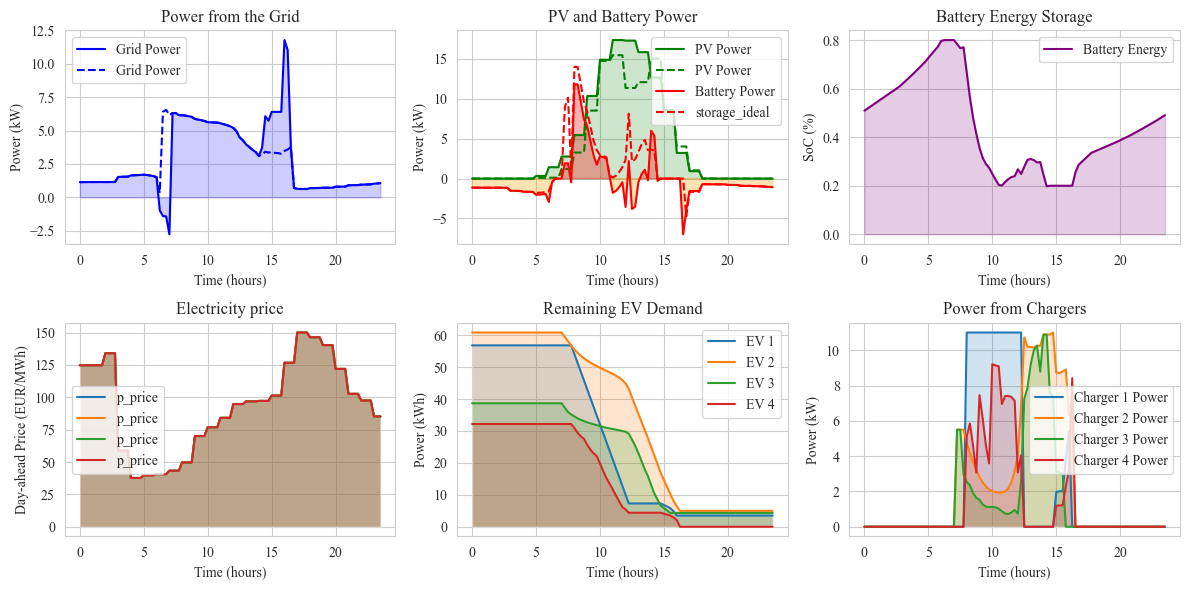

In [ ]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*50
                                + smoothing_penalty
                                + time_penalty)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4


# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
# Initialize storage energy
storage_energy_initial = np.array([storage_capacity]) / 2
# Initialize EV demand
real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'p_storage_ideal':  np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'p_chargers_ideal':       np.zeros((1, num_chargers)),
    'remaining_demand': real_energies_initial,
}

ev_errors = []
for t in tqdm(range(1, num_time_steps)):
    if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
    # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
    if t in (real_arrivals*4).astype(int):
        # Sample once for estimate
        new_durations_sample = sample_duration_given_arrival(mdn2, t/4)
        # Update estimated arrivals and durations
        est_arrivals[np.where((real_arrivals*4).astype(int) == t)] = t/4
        est_durations[np.where((real_arrivals*4).astype(int) == t)] = new_durations_sample
        est_energies[np.where((real_arrivals*4).astype(int) == t)] = real_energies[np.where((real_arrivals*4).astype(int) == t)]
        # Update estimated availability matrix
        est_availability_matrix = compute_availability(est_arrivals, est_durations)
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
        print(f"updated information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
        

    if t%time_shift==0:
        # Forecast and real PV generation (kW)
        p_pv = expanded_pv_forecast[t-1:] / 1000
        p_pv_real = expanded_pv[t-1:] / 1000
        # Charger availability masks
        charger_availability = est_availability[t-1:, :mpc.num_chargers]
        charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
        # Price and emissions
        p_price = expanded_price[t-1:]
        e_factor = expanded_emmision[t-1:]

        # Run MPC step
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

        # Apply real availability to ideal command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

        # Compute availability gap (newly available chargers)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Remaining energy demand (kWh) per charger at start of this window
        remaining_demand = results['remaining_demand'][-1].copy()

        # Compute total existing charging power for chargers that are already active
        existing_charging_power = np.sum(
            adjusted_p_chargers[~availability_gap]  # chargers not newly available
        )

        # Compute grid headroom: subtract already committed charging from max grid usage
        raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
        grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

        # Consider only chargers that are newly available at least once in this window
        newly_available_mask = np.any(availability_gap, axis=0)
        relevant_demand = remaining_demand * newly_available_mask
        total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

        # Precompute weighted per-charger limit based on demand for newly available chargers
        weights = np.abs(relevant_demand / total_demand)
        per_charger_limit = weights * grid_headroom

        # Adjust newly available chargers up to their weighted limit or remaining demand
        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Max power based on remaining energy demand
                    demand_limit = remaining_demand[j] / mpc.time_resolution
                    # Weighted grid limit for this charger
                    grid_limit_j = per_charger_limit[j]
                    # Clip between zero and the smaller of demand_limit and grid_limit_j
                    adjusted_p_chargers[i, j] = np.clip(
                        demand_limit,  # base from ideal command
                        0,
                        min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                    )
        # if t == 60: break
        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
            
            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
        # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.plot(time_steps, results['p_grid_ideal'], label='Grid Power', color='blue', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, label='PV Power', color='green', linestyle='--')

plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.plot(time_steps, results['p_storage_ideal'], label='storage_ideal', color='red', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

### a) dynamics uncertainty: dev notebook

### a) PV uncertainty

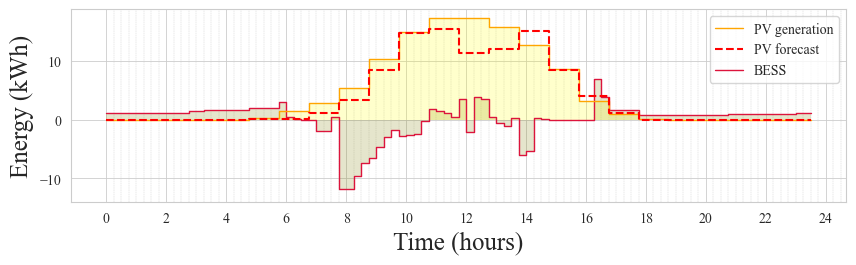

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.5))

# Plot for ax1 (Battery Power)
ax1.fill_between(time_steps, -results['p_storage'], label='BESS', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, -results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='BESS')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Energy (kWh)', size=18)
ax1.set_ylim([-14, 18.8])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)


# Plot for ax2 (Storage SoC)
ax1.fill_between(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV panel', color='yellow', alpha=0.2, edgecolor='None', step="pre")
line2, = ax1.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, color='orange', linewidth=1, drawstyle='steps', label='PV generation')
line2b, = ax1.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, '--', color='red', linewidth=1.5, drawstyle='steps', label='PV forecast')

# line2, = ax2.plot(time_steps, p_pv, '--', label='SoC', color='orange', alpha=0.6, linewidth=1.5, drawstyle='steps')


# Combine legends from both axes
lines = [line2, line2b, line1]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)

# Save the figure
plt.savefig('res_pv.png', dpi=300, bbox_inches='tight', pad_inches=0)


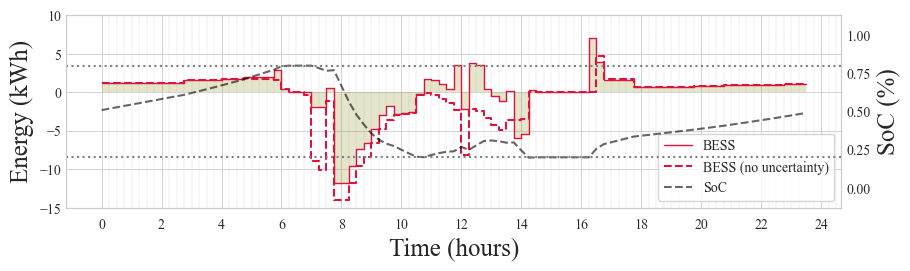

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.5))

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, -results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, -results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='BESS')
line1b, = ax1.plot(time_steps, -results['p_storage_ideal'], '--', color='crimson', linewidth=1.5, drawstyle='steps', label='BESS (no uncertainty)')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Energy (kWh)', size=18)
ax1.set_ylim([-15, 10])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '--', label='SoC', color='black', alpha=0.6, linewidth=1.5)
# Horizontal lines for min and max SoC
ax2.axhline(0.2, color='gray', linestyle=':', linewidth=1.5, label='Min SoC')
ax2.axhline(0.8, color='gray', linestyle=':', linewidth=1.5, label='Max SoC')

ax2.set_ylabel('SoC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line1b, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=10)
# Remove y-axis ticks (but keep labels)
ax1.tick_params(axis='y', length=0)  # For left y-axis
ax2.tick_params(axis='y', length=0)  # For right y-axis

# Save the figure
plt.savefig('res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


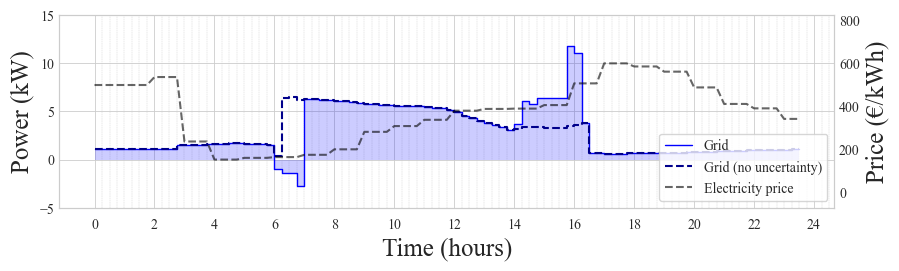

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.5))

# Plot for ax1 (Grid Power)
plt.fill_between(time_steps, results['p_grid'], label='Power', color='blue', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_grid'], color='blue', linewidth=1, drawstyle='steps', label='Grid')
line1b, = ax1.plot(time_steps, results['p_grid_ideal'], '--', color='darkblue', linewidth=1.5, drawstyle='steps', label='Grid (no uncertainty)')


ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-5,15])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Price)
line2, = ax2.plot(time_steps, expanded_price[1:1+len(time_steps)]*4, '--', label='Electricity price', color='black', alpha=0.6, linewidth=1.5)
ax2.set_ylabel('Price (€/kWh)', size=18)
price_span = expanded_price[1:1+len(time_steps)].max()*4-expanded_price[1:1+len(time_steps)].min()*4
plt.ylim([expanded_price[1:1+len(time_steps)].min()*4-price_span/2,expanded_price[1:1+len(time_steps)].max()*4+price_span/2+0.012])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line1b, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=10)
# Remove y-axis ticks (but keep labels)
ax1.tick_params(axis='y', length=0)  # For left y-axis
ax2.tick_params(axis='y', length=0)  # For right y-axis

# Save the figure
plt.savefig('res_grid.png', dpi=300, bbox_inches='tight', pad_inches=0)


### a) EV uncertainty

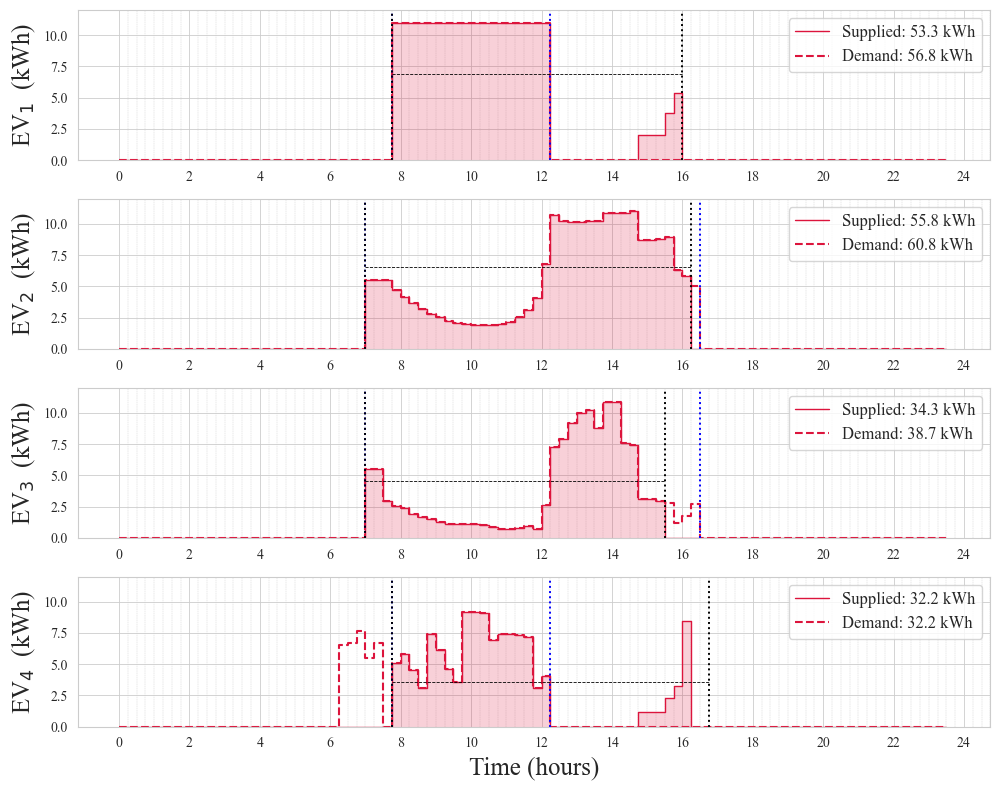

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

applied_demand = np.sum(results['p_chargers'], axis=0)/4

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 8))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps, results['p_chargers'][:,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps, results['p_chargers'][:,i], color='crimson', linewidth=1, drawstyle='steps', label=f'Supplied: {applied_demand[i]:.1f} kWh')
    line2, = axes[i].plot(time_steps, results['p_chargers_ideal'][:,i], '--', color='crimson', linewidth=1.5, drawstyle='steps', label=f'Demand: {real_energies_initial[0,i]:.1f} kWh')

    ts = np.where(est_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'blue', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'blue', linestyle=':', linewidth=1.4)

    ts = np.where(real_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=1.4)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(real_energies_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'EV$_{{{i+1}}}$  (kWh)', size=18)
    axes[i].set_ylim([0, 12])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(0, 25, 0.25)
    major_hours = np.arange(0, 25, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='upper right', fontsize=12)

axes[i].set_xlabel('Time (hours)', size=18)
plt.tight_layout()
# Save the figure
plt.savefig('res_chargers.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
